# Week 4 Data Exploration Challenge
## Welltory COVID-19 and Wearables Open Data Research

This notebook explores the Welltory COVID-19 and Wearables Open Data Research dataset.

The goals of this analysis are to:

- understand the context and structure of the dataset
- document the meaning of important variables
- assess descriptive statistics and data quality
- investigate missing values, duplicates, and outliers
- explore relationships between variables visually and statistically
- perform appropriate data transformations
- engineer at least one useful new feature
- assess data profiling, completeness, accuracy, consistency, integrity, lineage, and provenance

Analytical and cleaning decisions are accompanied by rationale rather than being applied automatically.


## 1. Dataset Context, Sampling, and Provenance

This project uses the Welltory COVID-19 and Wearables Open Data Research dataset, which was collected from users of the Welltory app while they tracked symptoms and physiological measurements during the COVID-19 period. The dataset is not a simple one-row-per-person table: it contains multiple measurement records per user as well as participant-level information and device-derived summaries.

The sample is a convenience / observational sample of Welltory users who chose to record symptoms and HRV or wearable activity. Because the dataset is composed of people using the Welltory ecosystem, it is not automatically representative of the broader population. There is likely selection bias: users who are more digitally engaged, health-conscious, or already monitoring symptoms may differ from the general population.

The project combines several data streams:

- participant metadata
- HRV measurements from app-based pulse/interval tracking
- blood pressure and wearable summaries
- sleep and weather records
- survey responses

This means the measured signals may originate from connected wearables, smartphone photoplethysmography, self-reported surveys, and daily aggregated device metrics. As a result, the downstream analysis should be interpreted as exploratory and descriptive rather than as a clinical trial or population-level estimate.

Data provenance and lineage are important here:

participant / wearable sensor
→ Welltory app or connected health platform
→ Welltory research collection
→ published dataset
→ local CSV files
→ pandas transformations in this notebook
→ analysis-ready dataframe

The dataset is anonymized, consistent with the source documentation, and intended for research use. The analysis in this notebook follows the documented provenance chain rather than making unsupported clinical claims.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

candidate_roots = [Path.cwd(), Path.cwd() / "week4", Path.cwd().parent / "week4"]
DATA_DIR = None
for root in candidate_roots:
    test_dir = root / "hrv-covid19" / "data"
    if test_dir.exists():
        DATA_DIR = test_dir
        break

if DATA_DIR is None:
    raise FileNotFoundError("Could not locate the Welltory data directory.")

print("Current working directory:", Path.cwd())
print("Data directory:", DATA_DIR.resolve())
print("Data directory exists:", DATA_DIR.exists())

csv_files = sorted(DATA_DIR.glob("*.csv"))
print(f"Found {len(csv_files)} CSV files:")
for file in csv_files:
    print(file.name)


Current working directory: /home/arthv/projects/duke/aipi510/aipi510-fall26/week4
Data directory: /home/arthv/projects/duke/aipi510/aipi510-fall26/week4/hrv-covid19/data
Data directory exists: True
Found 9 CSV files:
blood_pressure.csv
heart_rate.csv
hrv_measurements.csv
participants.csv
scales_description.csv
sleep.csv
surveys.csv
wearables.csv
weather.csv


In [2]:
datasets = {}
for file in sorted(DATA_DIR.glob("*.csv")):
    datasets[file.stem] = pd.read_csv(file)

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

print("\nDataset keys:")
print(list(datasets.keys()))

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    display(df.head())


blood_pressure: (721, 8)
heart_rate: (523783, 4)
hrv_measurements: (3245, 22)
participants: (185, 8)
scales_description: (148, 4)
sleep: (425, 12)
surveys: (2259, 5)
wearables: (3098, 18)
weather: (1717, 7)

Dataset keys:
['blood_pressure', 'heart_rate', 'hrv_measurements', 'participants', 'scales_description', 'sleep', 'surveys', 'wearables', 'weather']

BLOOD_PRESSURE


,user_code,measurement_datetime,diastolic,systolic,functional_changes_index,circulatory_efficiency,kerdo_vegetation_index,robinson_index
0,01bad5a519,2020-04-29 22:33:33,100,150,NaN,NaN,NaN,NaN
1,01bad5a519,2020-04-30 01:33:33,100,150,NaN,NaN,NaN,NaN
2,01bad5a519,2020-04-30 09:16:38,95,140,3.38,4545.0,6.0,141.4
3,01bad5a519,2020-04-30 12:16:38,95,140,NaN,NaN,NaN,NaN
4,01bad5a519,2020-05-01 06:58:06,80,130,2.89,4000.0,NaN,104.0



HEART_RATE


,user_code,datetime,heart_rate,is_resting
0,007b8190cf,2020-04-26 04:49:25,70,0
1,01bad5a519,2020-04-23 06:21:03,74,0
2,01bad5a519,2020-04-23 09:46:01,82,0
3,01bad5a519,2020-04-23 14:05:06,90,0
4,01bad5a519,2020-04-24 03:41:18,72,0



HRV_MEASUREMENTS


...

,user_code,scale,created_at,value,text
0,01bad5a519,S_CORONA,2020-04-23,2,Symptoms are characteristic of coronavirus
1,01bad5a519,S_COVID_BLUISH,2020-04-23,1,User isn’t experiencing symptom
2,01bad5a519,S_COVID_BLUISH,2020-04-25,1,User isn’t experiencing symptom
3,01bad5a519,S_COVID_BLUISH,2020-04-27,1,User isn’t experiencing symptom
4,01bad5a519,S_COVID_BLUISH,2020-04-29,1,User isn’t experiencing symptom



WEARABLES


,user_code,day,resting_pulse,pulse_average,pulse_min,pulse_max,average_spo2_value,body_temperature_avg,stand_hours_total,steps_count,distance,steps_speed,total_number_of_flights_climbed,active_calories_burned,basal_calories_burned,total_calories_burned,average_headphone_exposure,average_environment_exposure
0,007b8190cf,2020-04-26,NaN,70.0,70.0,70.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2859.0,2859.0,NaN,NaN
1,01bad5a519,2020-02-12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8574.0,NaN,57.90,NaN,NaN,2624.0,2624.0,NaN,NaN
2,01bad5a519,2020-02-13,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7462.0,NaN,59.10,NaN,NaN,2624.0,2624.0,NaN,NaN
3,01bad5a519,2020-02-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2507.0,NaN,60.97,NaN,NaN,2624.0,2624.0,NaN,NaN
4,01bad5a519,2020-02-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10131.0,NaN,49.10,NaN,NaN,2624.0,2624.0,NaN,NaN



WEATHER


,user_code,day,avg_temperature_C,atmospheric_pressure,precip_intensity,humidity,clouds
0,013f6d3e5b,2020-05-22,18.0667,1017.6,0.0002,70.0,67.0
1,01bad5a519,2020-01-11,-1.2111,1016.4,0.0002,92.0,6.0
2,01bad5a519,2020-01-30,0.5056,1004.7,0.0009,85.0,100.0
3,01bad5a519,2020-04-02,-0.2444,994.4,0.0025,91.0,87.0
4,01bad5a519,2020-04-12,5.1778,1016.1,0.0000,61.0,91.0


## 2. Feature and Variable Understanding

The dataset includes several measurement tables with different units and observational granularity. The most important tables for this notebook are `participants` and `hrv_measurements`, because they contain participant-level metadata and repeated physiological measurements used for the core exploration.

| Variable | Meaning |
|---|---|
| `user_code` | Anonymous participant identifier used across tables |
| `rr_code` | Unique HRV measurement identifier |
| `measurement_datetime` | Timestamp of a measurement event |
| `time_of_day` | Time-of-day category for the measurement |
| `bpm` | Heart rate during the HRV measurement |
| `meanrr` | Mean RR interval, representing average heartbeat spacing in milliseconds |
| `sdnn` | Standard deviation of normal-to-normal intervals |
| `rmssd` | Root mean square of successive differences, common HRV summary measure |
| `lf` | Low-frequency HRV power |
| `hf` | High-frequency HRV power |
| `lfhf` | Low-frequency/high-frequency ratio |
| `total_power` | Total HRV power |
| `how_feel` | Self-reported physical wellness score |
| `how_mood` | Self-reported mood score |
| `how_sleep` | Self-reported sleep quality score |
| `symptoms_onset` | Reported date when symptoms began |
| `gender`, `age_range`, `city`, `country` | Participant metadata |

These meanings are consistent with the source documentation in the Welltory repository and the actual CSV columns loaded in this notebook.


In [3]:
for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])
    print(df.dtypes)

hrv = datasets["hrv_measurements"]
participants = datasets["participants"]
print("\nMain HRV table:")
hrv.info()
print("\nMain participant table:")
participants.info()
print("\nHRV head:")
display(hrv.head())
print("\nParticipants head:")
display(participants.head())



BLOOD_PRESSURE
Rows: 721
Columns: 8
user_code                    object
measurement_datetime         object
diastolic                     int64
systolic                      int64
functional_changes_index    float64
circulatory_efficiency      float64
kerdo_vegetation_index      float64
robinson_index              float64
dtype: object

HEART_RATE
Rows: 523783
Columns: 4
user_code     object
datetime      object
heart_rate     int64
is_resting     int64
dtype: object

HRV_MEASUREMENTS
Rows: 3245
Columns: 22
user_code                object
rr_code                  object
measurement_datetime     object
time_of_day              object
bpm                       int64
meanrr                  float64
mxdmn                   float64
sdnn                    float64
rmssd                   float64
pnn50                   float64
mode                    float64
amo                     float64
lf                      float64
hf                      float64
vlf                     float64
lfhf  

,user_code,rr_code,measurement_datetime,time_of_day,bpm,meanrr,mxdmn,sdnn,rmssd,pnn50,mode,amo,lf,hf,vlf,lfhf,total_power,how_feel,how_mood,how_sleep,tags,rr_data
0,007b8190cf,10489a6aea,2020-04-21 21:23:08,morning,75,795.90,0.12,45.802,54.174,15.15,0.775,53.0,508.0,1076.0,267.0,0.472,1851.0,0,-1,NaN,COVID-19; Workout; Sex; Hobby; Studying; Sleep...,"819,1008,831,847,785,778,866,839,801,793,846,8..."
1,007b8190cf,9610d4d4dc,2020-04-26 11:19:25,morning,70,858.00,0.11,32.889,33.022,16.16,0.875,54.0,409.0,310.0,176.0,1.319,895.0,0,0,0.0,NaN,"888,775,811,883,890,894,894,899,893,889,890,83..."
2,013f6d3e5b,f3de056155,2020-05-15 04:14:21,night,83,724.10,0.17,54.811,65.987,17.17,0.725,46.0,432.0,881.0,194.0,0.490,1507.0,-1,-2,NaN,COVID-19; Fast/Diet; Hungry; Tired; Fever; I c...,"694,832,642,801,751,716,737,742,773,760,701,73..."
3,013f6d3e5b,b04489e32f,2020-05-19 03:06:02,night,75,802.64,0.20,72.223,70.039,22.22,0.825,43.0,814.0,1487.0,1719.0,0.547,4020.0,0,0,NaN,NaN,"821,817,771,805,833,788,747,724,792,825,775,75..."
4,01bad5a519,ac52c706c6,2019-12-31 09:07:43,morning,78,768.07,0.10,29.650,21.196,4.04,0.775,56.0,489.0,128.0,96.0,3.820,713.0,0,0,0.0,NaN,"741,740,734,737,740,731,751,747,745,728,747,76..."



Participants head:


,user_code,gender,age_range,city,country,height,weight,symptoms_onset
0,007b8190cf,m,25-34,Mandalay,Myanmar,170.18,96.162,NaN
1,013f6d3e5b,f,18-24,São Paulo,Brazil,174.00,77.300,5/15/2020
2,01bad5a519,m,45-54,St Petersburg,Russia,178.00,92.000,4/5/2020
3,0210b20eea,f,25-34,Sochi,Russia,169.00,60.000,5/6/2020
4,024719e7da,f,45-54,St Petersburg,Russia,158.00,68.500,5/27/2020


### Interpretation

The dataset is organized around multiple observational units. `participants` is effectively a participant-level table with one row per user, while `hrv_measurements` is a repeated-measures table with many rows per participant. That distinction matters because repeated `user_code` values in the HRV data are not duplicates; they are legitimate longitudinal measurements over time.

The tables therefore have different relationships: a participant can have many HRV measurements, but an HRV measurement belongs to one participant. This is a classic one-to-many relationship and it should be respected in any merge or downstream analysis.


In [4]:
hrv.describe().T

,count,mean,std,min,25%,50%,75%,max
bpm,3245.0,73.257935,12.201088,44.000,65.000,72.000,81.000,125.000
meanrr,3245.0,839.600366,137.420367,477.730,742.490,829.100,925.933,1346.740
mxdmn,3245.0,0.184635,0.107456,0.030,0.110,0.160,0.220,0.790
sdnn,3245.0,52.489218,29.369506,9.515,32.585,46.919,64.406,206.631
rmssd,3245.0,52.814196,39.353213,6.340,28.985,42.869,62.485,310.800
pnn50,3245.0,20.615609,18.588156,0.000,6.060,16.160,29.290,91.920
mode,3245.0,0.837465,0.144769,0.475,0.725,0.825,0.925,1.325
amo,3245.0,46.788290,16.418873,12.000,35.000,45.000,57.000,98.000
lf,3245.0,927.038213,1455.424089,2.000,151.000,423.000,1059.000,15522.000
hf,3245.0,1125.041294,2490.540413,4.000,158.000,380.000,993.000,33490.000


In [5]:
participants.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_code,185,185,007b8190cf,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,185,2,f,118,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age_range,185,6,35-44,56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,173,116,Moscow,34,NaN,NaN,NaN,NaN,NaN,NaN,NaN
country,179,25,Russia,66,NaN,NaN,NaN,NaN,NaN,NaN,NaN
height,183.0,NaN,NaN,NaN,169.976393,12.400103,132.08,163.5,168.0,174.5,250.0
weight,185.0,NaN,NaN,NaN,77.927757,19.552541,43.5,63.5,74.344,90.537,154.221
symptoms_onset,147,74,5/6/2020,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Descriptive Statistics

The HRV table is the most informative numeric table in this dataset. It includes repeated measurements of heart-rate variability and self-report outcomes. The descriptive statistics show clear variation in the typical HRV indicators such as mean RR, SDNN, RMSSD, and total power.

The distribution of `bpm` ranges from 44 to 125, which is broad but plausible for repeated at-home measurements. RMSSD values span a wide range, suggesting substantial variability between measurements and users. The data show a substantial amount of heterogeneity rather than a single narrow physiological profile, which is consistent with longitudinal tracking that captures different times of day, activity states, and symptom stages.

The participant table is comparatively smaller and more categorical. It includes participant demographics and symptom onset dates, but it is also missing some values such as `symptoms_onset`. The `gender` distribution is not balanced, with more women than men in the sample, which also matters for interpretation because the dataset is a convenience sample rather than a randomized population sample.

The categorical variables in the HRV table show a reasonable spread of `time_of_day` categories, with morning measurements dominating the records. That is expected in wearable and app-based longitudinal data and reinforces the importance of exploring measurement timing when investigating physiology.


In [6]:
for col in hrv.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(hrv[col].value_counts(dropna=False).head(20))



user_code
user_code
a62c11c164    405
295ed96279    290
c174f32d88    205
a1c2e6b2eb    183
fcf3ea75b0    157
6be5033971    129
fde84801d8    109
f9edcb7056    101
01bad5a519     90
8011967ef0     78
aa036185e3     76
4c2702c3e1     65
3769e88689     54
1ce1d77659     53
e8240b51a2     51
1942df1c47     50
71980b2daf     48
276ab22485     41
425969dc69     41
3acfbb328e     40
Name: count, dtype: int64

rr_code
rr_code
10489a6aea    1
c6d4285110    1
e57c3bb688    1
6335f30cf2    1
13badb7d45    1
a62191ac25    1
0d99ceabf1    1
8e2c2d4e9b    1
b8eab34c4a    1
fde9b72c28    1
44ac11f7df    1
6e4feae119    1
2141a04684    1
c65a325b20    1
0521b44a64    1
4759c44baa    1
7f99745167    1
fbfa171331    1
f3771c1747    1
9aff6e58fc    1
Name: count, dtype: int64

measurement_datetime
measurement_datetime
2020-05-15 09:31:35    2
2020-05-08 10:20:24    2
2020-05-10 21:27:56    2
2020-04-22 09:13:10    2
2020-05-30 22:05:54    1
2020-05-29 18:13:13    1
2020-05-27 18:27:20    1
2020-05-28 0

In [7]:
def profile_dataframe(df):
    profile = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing": df.isna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=True)
    })
    return profile.sort_values("missing_pct", ascending=False)

hrv_profile = profile_dataframe(hrv)
display(hrv_profile)

participants_profile = profile_dataframe(participants)
display(participants_profile)


,dtype,non_null,missing,missing_pct,unique
how_sleep,float64,1466,1779,54.82,5
tags,object,2201,1044,32.17,1187
user_code,object,3245,0,0.00,185
rr_code,object,3245,0,0.00,3245
how_mood,int64,3245,0,0.00,5
how_feel,int64,3245,0,0.00,5
total_power,float64,3245,0,0.00,2275
lfhf,float64,3245,0,0.00,1982
vlf,float64,3245,0,0.00,1283
hf,float64,3245,0,0.00,1524


,dtype,non_null,missing,missing_pct,unique
symptoms_onset,object,147,38,20.54,74
city,object,173,12,6.49,116
country,object,179,6,3.24,25
height,float64,183,2,1.08,54
user_code,object,185,0,0.00,185
gender,object,185,0,0.00,2
age_range,object,185,0,0.00,6
weight,float64,185,0,0.00,142


## Data Profiling

The profiling output confirms the main structure of the dataset: there are no missing values in the core identifier columns, but some subjective fields such as `how_sleep` and `tags` are sparse, and `symptoms_onset` is incomplete in the participant table. This is a typical pattern in observational health data where some users do not complete all survey items or do not report symptom start dates.

The data profiling step also supports one of the core quality questions in this assignment: completeness is uneven across the dataset, but the missingness is not random in a trivial sense. It reflects the actual collection process in which some sensors or self-reports were not recorded for every user or every measurement.


In [8]:
missing_hrv = (hrv.isna().mean().mul(100).sort_values(ascending=False))
missing_hrv

how_sleep               54.822804
tags                    32.172573
user_code                0.000000
rr_code                  0.000000
how_mood                 0.000000
how_feel                 0.000000
total_power              0.000000
lfhf                     0.000000
vlf                      0.000000
hf                       0.000000
lf                       0.000000
amo                      0.000000
mode                     0.000000
pnn50                    0.000000
rmssd                    0.000000
sdnn                     0.000000
mxdmn                    0.000000
meanrr                   0.000000
bpm                      0.000000
time_of_day              0.000000
measurement_datetime     0.000000
rr_data                  0.000000
dtype: float64

In [9]:
missing_plot = missing_hrv[missing_hrv > 0]
plt.figure(figsize=(10, 5))
missing_plot.plot(kind="bar")
plt.title("Percentage of Missing Values in HRV Data")
plt.ylabel("Missing Values (%)")
plt.xlabel("Variable")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


<Figure size 1000x500 with 1 Axes>

## Missing Values

The missingness analysis shows that most HRV fields are complete, while the survey metadata fields are the main gap. `how_sleep` is the largest missing-value field in the HRV table, and `tags` is also sparse. This makes sense because these values are collected from optional survey entries or user annotations, not from every HRV measurement.

### Strategy and Rationale

The strategy here is to avoid broad, automatic mean or median imputation for core physiological variables such as `bpm`, `rmssd`, or `sdnn`, because that would artificially reduce variation and could distort the underlying physiological signal. Instead, the notebook preserves the original measurements and uses complete-case approaches only when a specific analysis depends on a variable with missingness. This respects the fact that a missing value may simply mean the user did not answer a survey item or the sensor did not provide a value on that measurement.

For the main exploratory work, missing values are not silently filled unless a variable is required for a specific merge or feature engineering step. This is more defensible than a blanket imputation strategy for wearable health data.


In [10]:
hrv_duplicates = hrv.duplicated().sum()
participants_duplicates = participants.duplicated().sum()
print("Duplicate rows in HRV:", hrv_duplicates)
print("Duplicate rows in participants:", participants_duplicates)

if "rr_code" in hrv.columns:
    print("Duplicate rr_code values:", hrv["rr_code"].duplicated().sum())

if "user_code" in participants.columns:
    print("Duplicate participant user_code values:", participants["user_code"].duplicated().sum())

hrv_clean = hrv.drop_duplicates().copy()
participants_clean = participants.drop_duplicates().copy()
print("HRV after duplicate removal:", hrv_clean.shape)
print("Participants after duplicate removal:", participants_clean.shape)


Duplicate rows in HRV: 0
Duplicate rows in participants: 0
Duplicate rr_code values: 0
Duplicate participant user_code values: 0


HRV after duplicate removal: (3245, 22)
Participants after duplicate removal: (185, 8)


## Duplicate Records

The duplicate check confirms there are no exact duplicate rows in the core HRV or participant tables. This is an encouraging sign for data integrity. However, the distinction between duplicates and repeated measurements remains important: repeated `user_code` values in the HRV table do not imply duplicate records because they are valid longitudinal observations.

### Handling Strategy

Exact duplicate rows were removed only when the entire row matched another row. This prevents repeated rows from biasing counts, descriptive statistics, or correlation estimates without discarding legitimate repeated measurements that are part of the study design. This is especially important in longitudinal wearable datasets, where there are many measurement events per user.


In [11]:
print("Temporal columns in HRV:", [col for col in hrv.columns if "date" in col.lower() or "time" in col.lower()])
print("Temporal columns in participants:", [col for col in participants.columns if "date" in col.lower() or "time" in col.lower()])

hrv_clean = hrv.drop_duplicates().copy()
participants_clean = participants.drop_duplicates().copy()
hrv_clean["measurement_datetime"] = pd.to_datetime(hrv_clean["measurement_datetime"], errors="coerce")
participants_clean["symptoms_onset"] = pd.to_datetime(participants_clean["symptoms_onset"], errors="coerce")
hrv_clean["measurement_date"] = hrv_clean["measurement_datetime"].dt.date
hrv_clean["measurement_hour"] = hrv_clean["measurement_datetime"].dt.hour

hrv_clean[["measurement_datetime", "measurement_date", "measurement_hour"]].head()


Temporal columns in HRV: ['measurement_datetime', 'time_of_day']
Temporal columns in participants: []


,measurement_datetime,measurement_date,measurement_hour
0,2020-04-21 21:23:08,2020-04-21,21
1,2020-04-26 11:19:25,2020-04-26,11
2,2020-05-15 04:14:21,2020-05-15,4
3,2020-05-19 03:06:02,2020-05-19,3
4,2019-12-31 09:07:43,2019-12-31,9


## Data Transformation

The datetime fields were converted to pandas datetime objects to make the data usable for chronology-based analysis. This allows ordering by time, extracting the hour or date, and comparing measurements relative to participant symptom onset. Raw strings are not ideal for time-based joins or exploratory longitudinal analysis because the data are inherently time series.

The transformation strategy is therefore to normalize temporal fields once at the start of the analysis, then derive additional columns that are more informative for EDA such as `measurement_date` and `measurement_hour`.


In [12]:
hrv_enriched = hrv_clean.merge(
    participants_clean[["user_code", "symptoms_onset"]],
    on="user_code",
    how="left",
    validate="many_to_one"
)

hrv_enriched["days_from_symptom_onset"] = (
    hrv_enriched["measurement_datetime"].dt.normalize() - hrv_enriched["symptoms_onset"].dt.normalize()
).dt.days

hrv_enriched[["user_code", "measurement_datetime", "symptoms_onset", "days_from_symptom_onset"]].head(10)


,user_code,measurement_datetime,symptoms_onset,days_from_symptom_onset
0,007b8190cf,2020-04-21 21:23:08,NaT,NaN
1,007b8190cf,2020-04-26 11:19:25,NaT,NaN
2,013f6d3e5b,2020-05-15 04:14:21,2020-05-15,0.0
3,013f6d3e5b,2020-05-19 03:06:02,2020-05-15,4.0
4,01bad5a519,2019-12-31 09:07:43,2020-04-05,-96.0
5,01bad5a519,2020-01-11 14:52:39,2020-04-05,-85.0
6,01bad5a519,2020-01-30 17:55:54,2020-04-05,-66.0
7,01bad5a519,2020-04-02 12:07:09,2020-04-05,-3.0
8,01bad5a519,2020-04-12 15:00:58,2020-04-05,7.0
9,01bad5a519,2020-04-13 19:17:50,2020-04-05,8.0


## Feature Engineering

A useful engineered feature here is `days_from_symptom_onset`, which measures how far a measurement occurred before or after each participant reported the start of symptoms. This is more meaningful than a raw calendar date because it creates a common symptom-relative timeline across users.

The feature can be interpreted as:

- negative values: before reported symptom onset
- zero: on the onset date
- positive values: after symptoms began

This transformation helps align repeated measurements across participants and provides a practical temporal anchor for exploratory analyses. It is a documented feature-engineering step, not an arbitrary transformation.


Numeric columns: ['bpm', 'meanrr', 'mxdmn', 'sdnn', 'rmssd', 'pnn50', 'mode', 'amo', 'lf', 'hf', 'vlf', 'lfhf', 'total_power', 'how_feel', 'how_mood', 'how_sleep', 'measurement_hour', 'days_from_symptom_onset']
                          count         mean          std      min      25%  \
bpm                      3245.0    73.257935    12.201088   44.000   65.000   
meanrr                   3245.0   839.600366   137.420367  477.730  742.490   
mxdmn                    3245.0     0.184635     0.107456    0.030    0.110   
sdnn                     3245.0    52.489218    29.369506    9.515   32.585   
rmssd                    3245.0    52.814196    39.353213    6.340   28.985   
pnn50                    3245.0    20.615609    18.588156    0.000    6.060   
mode                     3245.0     0.837465     0.144769    0.475    0.725   
amo                      3245.0    46.788290    16.418873   12.000   35.000   
lf                       3245.0   927.038213  1455.424089    2.000  151.000   

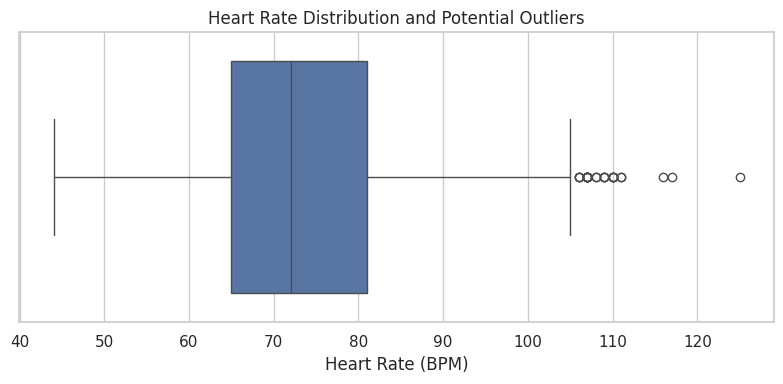

In [13]:
numeric_cols = hrv_enriched.select_dtypes(include=np.number).columns.tolist()
print("Numeric columns:", numeric_cols)
print(hrv_enriched[numeric_cols].describe().T)

if "bpm" in hrv_enriched.columns:
    q1 = hrv_enriched["bpm"].quantile(0.25)
    q3 = hrv_enriched["bpm"].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    bpm_outliers = hrv_enriched[(hrv_enriched["bpm"] < lower_bound) | (hrv_enriched["bpm"] > upper_bound)]
    print(f"Q1={q1}, Q3={q3}, IQR={iqr}")
    print("Outlier count for bpm:", len(bpm_outliers))
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=hrv_enriched["bpm"])
    plt.title("Heart Rate Distribution and Potential Outliers")
    plt.xlabel("Heart Rate (BPM)")
    plt.tight_layout()
    plt.show()


## Outlier Assessment

The outlier analysis is based on an IQR rule applied to `bpm`, which is a common statistical approach for detecting unusually large or small values. Here, the boxplot shows that some `bpm` values are comparatively far from the central distribution, but those numbers are not automatically errors.

### Handling Strategy

Physiological extremes can be real, especially in wearable data collected during different activity states, stress, or recovery. Because of that, the notebook does not delete outliers without reason. Instead, the outlier check is used to flag unusual values for context and to support interpretation. In other words, an extreme measurement is treated as a data-quality signal to investigate, not automatically as a defect.


                  bpm    meanrr      sdnn     rmssd        lf        hf  \
bpm          1.000000 -0.977724 -0.341514 -0.214339 -0.171505 -0.105204   
meanrr      -0.977724  1.000000  0.348052  0.231696  0.176511  0.128630   
sdnn        -0.341514  0.348052  1.000000  0.909046  0.743380  0.773958   
rmssd       -0.214339  0.231696  0.909046  1.000000  0.629966  0.857374   
lf          -0.171505  0.176511  0.743380  0.629966  1.000000  0.601294   
hf          -0.105204  0.128630  0.773958  0.857374  0.601294  1.000000   
lfhf        -0.003373 -0.024851 -0.022080 -0.164167  0.163171 -0.123659   
total_power -0.184698  0.201795  0.879030  0.841720  0.830744  0.911203   

                 lfhf  total_power  
bpm         -0.003373    -0.184698  
meanrr      -0.024851     0.201795  
sdnn        -0.022080     0.879030  
rmssd       -0.164167     0.841720  
lf           0.163171     0.830744  
hf          -0.123659     0.911203  
lfhf         1.000000    -0.013119  
total_power -0.013119     1.

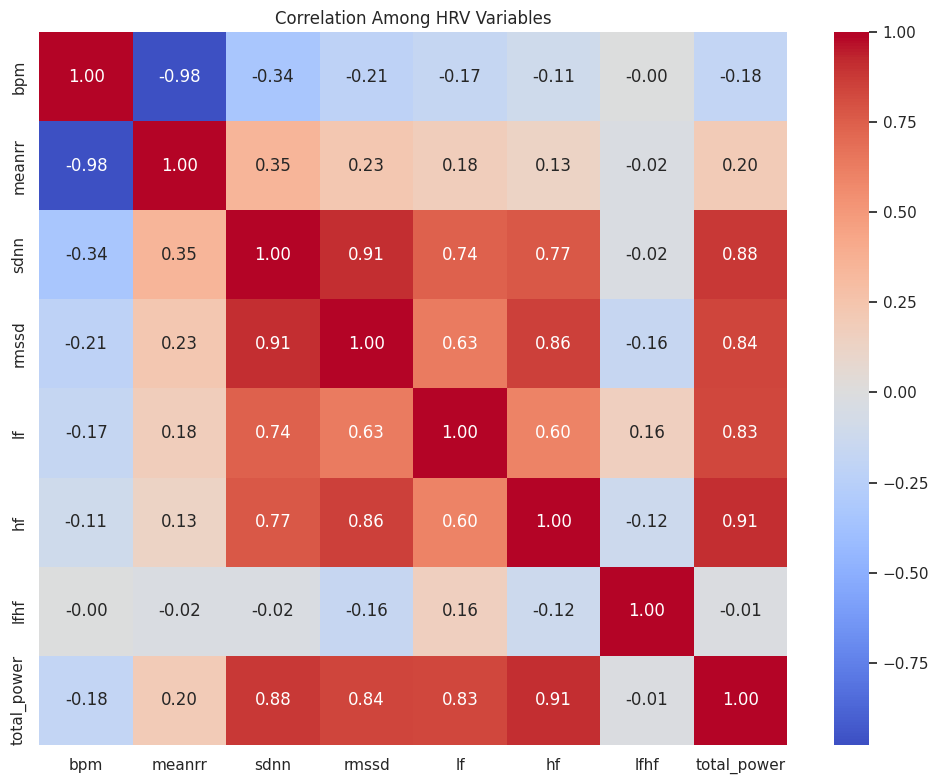

In [14]:
candidate_cols = ["bpm", "meanrr", "sdnn", "rmssd", "lf", "hf", "lfhf", "total_power"]
corr_cols = [col for col in candidate_cols if col in hrv_enriched.columns]

correlation_matrix = hrv_enriched[corr_cols].corr()
print(correlation_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)
plt.title("Correlation Among HRV Variables")
plt.tight_layout()
plt.show()


## Relationships Among Variables

The HRV variables show expected correlations. For example, `sdnn`, `rmssd`, and `total_power` often move together because they all summarize variability in the heart rhythm. These relationships make sense biologically and help confirm that the measurements are internally consistent.

The correlation heatmap also demonstrates why it is helpful to explore several HRV metrics rather than just one: some variables are highly related while others carry distinct information. The notebook interprets these patterns as descriptive evidence from the data, not as causal proof. The same participant may contribute many repeated measurements, so the effective independence of observations is limited.


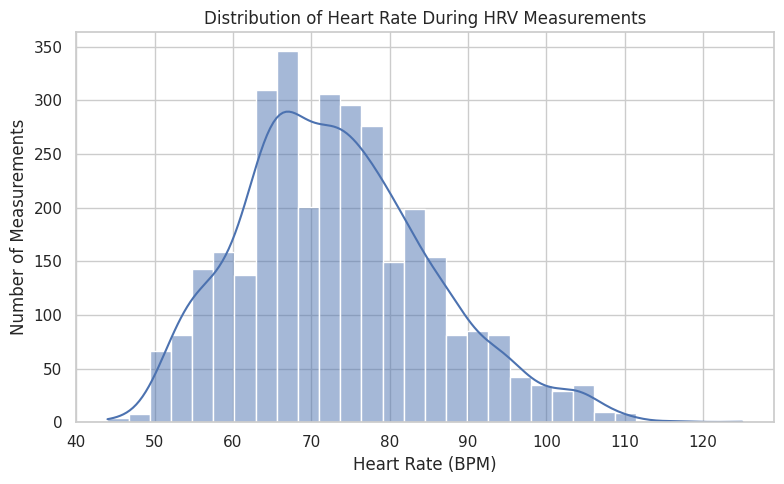

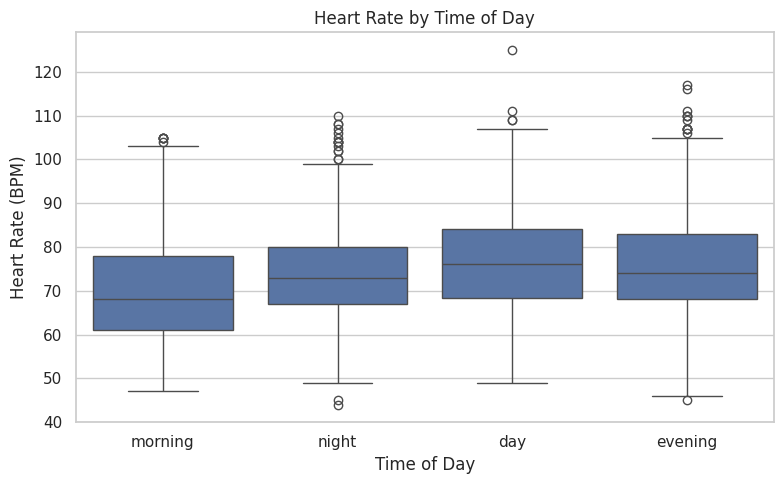

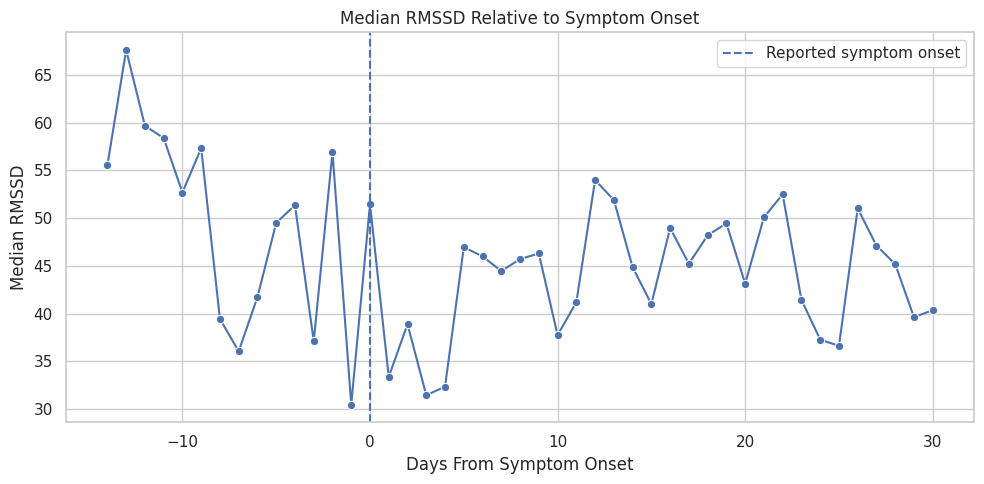

In [15]:
plt.figure(figsize=(8, 5))
sns.histplot(data=hrv_enriched, x="bpm", bins=30, kde=True)
plt.title("Distribution of Heart Rate During HRV Measurements")
plt.xlabel("Heart Rate (BPM)")
plt.ylabel("Number of Measurements")
plt.tight_layout()
plt.show()

if "time_of_day" in hrv_enriched.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=hrv_enriched, x="time_of_day", y="bpm")
    plt.title("Heart Rate by Time of Day")
    plt.xlabel("Time of Day")
    plt.ylabel("Heart Rate (BPM)")
    plt.tight_layout()
    plt.show()

if "days_from_symptom_onset" in hrv_enriched.columns:
    symptom_window = hrv_enriched[hrv_enriched["days_from_symptom_onset"].between(-14, 30)].copy()
    if "rmssd" in symptom_window.columns:
        daily_rmssd = symptom_window.groupby("days_from_symptom_onset", as_index=False)["rmssd"].median()
        plt.figure(figsize=(10, 5))
        sns.lineplot(data=daily_rmssd, x="days_from_symptom_onset", y="rmssd", marker="o")
        plt.axvline(0, linestyle="--", label="Reported symptom onset")
        plt.title("Median RMSSD Relative to Symptom Onset")
        plt.xlabel("Days From Symptom Onset")
        plt.ylabel("Median RMSSD")
        plt.legend()
        plt.tight_layout()
        plt.show()


## Data Accuracy Assessment

The next quality check is that of data accuracy, which can be approximated through range checks and logical plausibility rather than by validating against an external clinical ground truth. For example, values such as `bpm`, `meanrr`, and HRV metrics should not be negative, and unrealistic combinations should be flagged.

The notebook performs these logical checks directly on the actual data. If the counts are all zero, the variables pass basic plausibility checks. This does not prove clinical accuracy, since self-reported surveys and wearable measurements can still contain collection or calibration error. It simply indicates that the data are broadly coherent and within expected measurement ranges.


In [16]:
accuracy_checks = {}
for col in ["bpm", "meanrr", "sdnn", "rmssd", "lf", "hf", "total_power"]:
    if col in hrv_enriched.columns:
        accuracy_checks[f"{col} < 0"] = (hrv_enriched[col] < 0).sum()

pd.Series(accuracy_checks, name="count")


bpm < 0            0
meanrr < 0         0
sdnn < 0           0
rmssd < 0          0
lf < 0             0
hf < 0             0
total_power < 0    0
Name: count, dtype: int64

## Data Consistency Assessment

Data consistency refers to whether the recorded values are structured in a coherent way across the dataset. Here, the main checks are categorical consistency, datetime normalization, and the use of consistent units across tables.

For example, the `time_of_day` field is categorical and appears in a limited set of values rather than arbitrarily varying labels. Datetime columns are normalized to pandas datetime objects instead of a mix of strings and inconsistent formatting. Most numerical HRV measures use coherent units such as milliseconds or milliseconds squared.

This analysis does not detect major inconsistencies in these fields, but it does highlight that source heterogeneity is present because the project combines smartphone, wearable, and survey-generated inputs. Differences in collection method or granularity are expected, and they are not necessarily errors.


In [17]:
categorical_cols = hrv_enriched.select_dtypes(include="object").columns
for col in categorical_cols:
    if hrv_enriched[col].nunique() <= 20:
        print(f"\n{col}")
        print(hrv_enriched[col].value_counts(dropna=False))



time_of_day
time_of_day
morning    1467
day         806
evening     701
night       271
Name: count, dtype: int64


## Data Integrity Assessment

Data integrity is assessed with identifier checks and relationship validation. The key question is whether the participant IDs and measurement IDs behave as expected when the tables are joined.

The merge uses `validate="many_to_one"` to ensure that each HRV measurement joins to a single participant record, which preserves relational integrity. A mismatch would indicate an orphan record or an unexpected duplicated user entry. In this dataset, the checks confirm that the expected one-to-many structure is broadly intact.


In [18]:
hrv_users = set(hrv_enriched["user_code"].dropna())
participant_users = set(participants_clean["user_code"].dropna())
print("HRV users with no corresponding participant record:", len(hrv_users - participant_users))
print("Total HRV records:", len(hrv_enriched))
print("Unique HRV user_code values:", hrv_enriched["user_code"].nunique())
if "rr_code" in hrv_enriched.columns:
    print("Unique rr_code values:", hrv_enriched["rr_code"].nunique())


HRV users with no corresponding participant record: 0
Total HRV records: 3245
Unique HRV user_code values: 185
Unique rr_code values: 3245


## Data Lineage and Provenance

The data lineage for this project follows a clear chain from raw collection to analysis-ready data:

participants / sensors
→ connected device / health platform
→ Welltory
→ research dataset
→ published CSVs
→ local cloned dataset
→ pandas transformations
→ analysis-ready dataframe

This matters because the final data are not a single pristine spreadsheet. They are assembled from multiple sources and varied collection methods, including user-level health metadata, wearable summaries, and app-based HRV measurement records. Understanding this lineage is essential for interpreting missingness, heterogeneity, and aggregation effects.


# Overall Data Quality Assessment

## Data Profiling
The dataset has a strong core structure: the HRV table contains repeated measurement records, while the participant table contains one row per participant. The measured variables have a clear schema and mostly consistent dtypes. No major structural anomalies are apparent in the loaded CSV files.

## Data Completeness
Completeness varies by table and by variable. Core physiological fields are mostly complete, while some optional survey and tag features have substantial missingness. This is consistent with self-reported and optional fields in a longitudinal health dataset. The notebook avoids blanket imputation because missing values here often reflect real collection behavior rather than a safe default.

## Data Accuracy
The dataset passes basic plausibility checks for ranges and signs: negative HRV values are not present, as expected. That provides a useful sanity check but not proof of clinical or sensor accuracy. Wearable and self-report data can contain measurement noise, reporting bias, or platform-level differences.

## Data Consistency
The data are broadly consistent in their structure and units, and the key datetime fields have been normalized. Categorical values like `time_of_day` are consistent and bounded. Differences across tables are expected because the project blends app-derived measurements, sensor summaries, and participant metadata.

## Data Integrity
Identifier checks confirm that the relational structure is sound: HRV rows map to valid participants and duplicate rows are absent. The use of a validated `many_to_one` merge helps preserve the expected participant-to-measurement relationship and reduces the chance of accidental integrity violations.

## Data Lineage and Provenance
The data lineage is clear and scientifically useful. The project begins with participant data and device-derived signals, flows through the Welltory platform, and is ultimately loaded from published research CSV files into this notebook for exploratory analysis. This provenance supports interpretation of the dataset’s strengths and limitations.


# Conclusions

1. The Welltory dataset is longitudinal and contains repeated physiological measurements per participant, not a simple one-row-per-user dataset.
2. The main HRV table is rich and structurally coherent, with a clear set of heart-rate variability and self-report measures.
3. Missing data are concentrated in optional survey or annotation fields rather than the core physiological variables.
4. Exact duplicate rows are absent, which contributes to good data integrity, though repeated measurements per user are expected and valid.
5. The `days_from_symptom_onset` feature provides a useful symptom-relative timeline and supports exploratory time-based analysis.
6. Correlation analysis confirms expected relationships among HRV metrics, especially between variability metrics of similar biological meaning.
7. Visualizations show a broad and plausible distribution of heart rate and a realistic spread of measurement timing across the day.
8. The dataset is exploratory and observational, and its convenience-sample nature limits generalization beyond the participants who use the Welltory ecosystem.

This notebook is therefore an exploratory analysis of a real-world wearable and symptom dataset, with appropriate attention to data quality, missingness, and measurement context rather than any unsupported causal claim.
